In [2]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
iris = load_iris()

In [9]:
X = iris.data
y = iris.target

<Axes: >

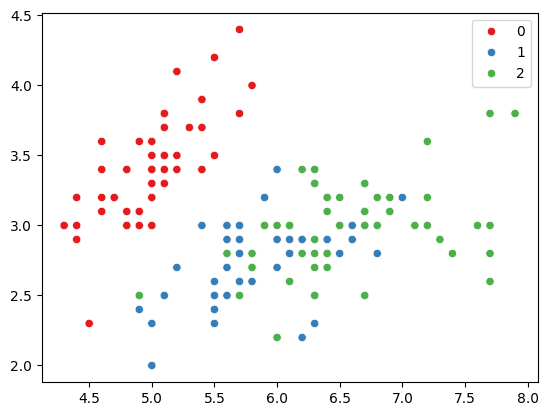

In [11]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1')

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [17]:
# dim redn
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_X = pca.fit_transform(scaled_X)

In [18]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(pca_X)
    wcss.append(kmeans.inertia_)

<Axes: >

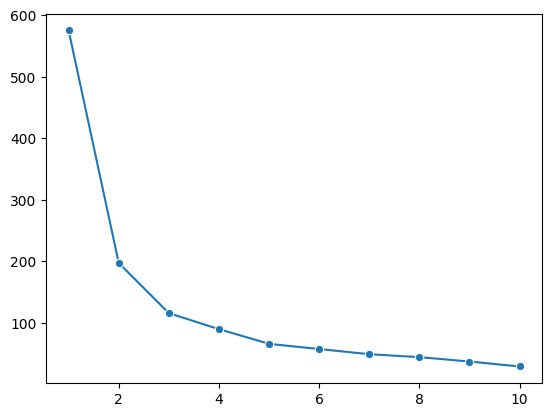

In [19]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

In [27]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_X)

<Axes: >

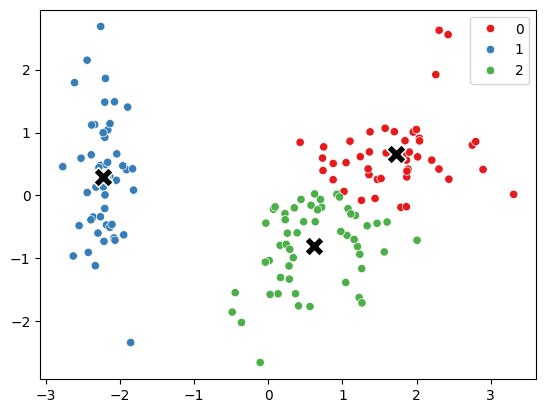

In [29]:
sns.scatterplot(x = pca_X[:, 0], y = pca_X[:, 1], hue = labels, palette='Set1')
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], color='black', s=200, marker='X')